In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

In [ ]:
# from google.colab import files
# upload=files.upload()

Saving archive (8).zip to archive (8) (1).zip


In [2]:
!unzip '/content/archive (8).zip'

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [3]:
!ls

'archive (8).zip'   sample_data   Testing   Training


In [4]:
import os
print(os.listdir("/content/Training"))

['meningioma', 'notumor', 'pituitary', 'glioma']


In [5]:
import os

cur_path = "/content/Training"

for folder in os.listdir(cur_path):
    path = os.path.join(cur_path, folder)
    print(f"{folder}: {len(os.listdir(path))} images")

meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images
glioma: 1400 images


In [6]:
import os
import numpy as np
from PIL import Image

data = []
labels = []

cur_path = "/content/Training"

classes = ['glioma','meningioma','notumor','pituitary']

for i, class_name in enumerate(classes):

    path = os.path.join(cur_path, class_name)
    images = os.listdir(path)

    for a in images:
     try:
        image = Image.open(os.path.join(path, a)).convert('RGB')
        image = image.resize((128,128))
        image = np.array(image)

        data.append(image)
        labels.append(i)

     except:
        print("Error loading image:", os.path.join(path, a))

print("Dataset loading complete!")
print("Total images loaded:", len(data))

Dataset loading complete!
Total images loaded: 5600


In [7]:
data = np.array(data)
labels = np.array(labels)

print(data.shape)
print(labels.shape)

(5600, 128, 128, 3)
(5600,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
data, labels, test_size=0.2, random_state=42)

In [9]:
# Normalizing the images
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
# Convert Labels to Categorical
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train,4)
y_test = to_categorical(y_test,4)

In [11]:
# CNN Model
from tensorflow.keras import layers, models

model = models.Sequential([

layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
layers.MaxPooling2D(2,2),

layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Conv2D(128,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Flatten(),

layers.Dense(128,activation='relu'),

layers.Dense(4,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [13]:
history = model.fit(
X_train,
y_train,
epochs=10,
validation_data=(X_test,y_test)
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 702ms/step - accuracy: 0.5833 - loss: 0.9612 - val_accuracy: 0.7893 - val_loss: 0.5415
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 138s 675ms/step - accuracy: 0.8355 - loss: 0.4287 - val_accuracy: 0.8509 - val_loss: 0.3700
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 144s 693ms/step - accuracy: 0.8826 - loss: 0.3085 - val_accuracy: 0.8884 - val_loss: 0.2970
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 717ms/step - accuracy: 0.9279 - loss: 0.1968 - val_accuracy: 0.9179 - val_loss: 0.2088
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 139s 695ms/step - accuracy: 0.9562 - loss: 0.1195 - val_accuracy: 0.9000 - val_loss: 0.2973
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 707ms/step - accuracy: 0.9772 - loss: 0.0651 - val_accuracy: 0.9304 - val_loss: 0.2375
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 139s 694ms/step - accuracy: 0.9857 - loss: 0.0449 - val_accuracy: 0.9375 - val_loss: 0.2026
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 712ms/step - accuracy: 0.9854 -

In [14]:
model.evaluate(X_test,y_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 356ms/step - accuracy: 0.9251 - loss: 0.2629


[0.23957479000091553, 0.9348214268684387]

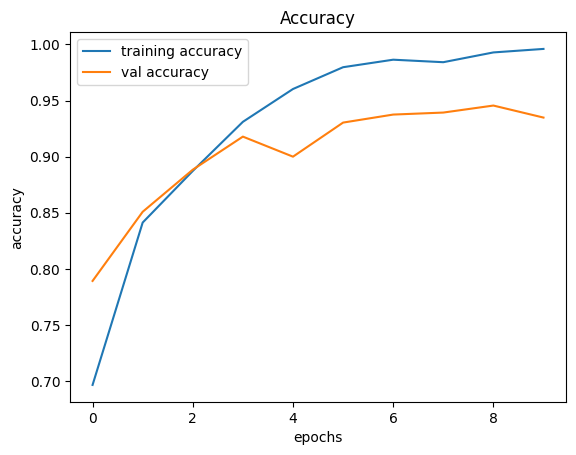

In [15]:
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

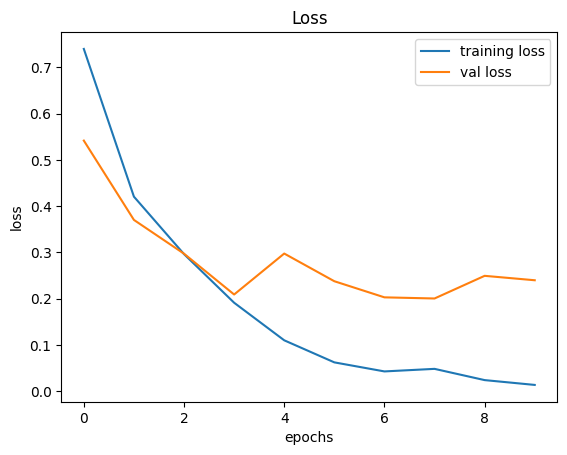

In [16]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import accuracy_score
import os
import numpy as np
from PIL import Image

data = []
labels = []

classes = ['glioma','meningioma','notumor','pituitary']

cur_path = "/content/Testing"

for i, class_name in enumerate(classes):

    path = os.path.join(cur_path, class_name)
    images = os.listdir(path)

    for img in images:
        image = Image.open(os.path.join(path,img)).convert('RGB')
        image = image.resize((128,128))
        data.append(np.array(image))
        labels.append(i)

X_test = np.array(data)
y_test = np.array(labels)

X_test = X_test/255.0

In [18]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step


In [19]:
print("Test Accuracy:", accuracy_score(y_test, pred_classes))

Test Accuracy: 0.875625


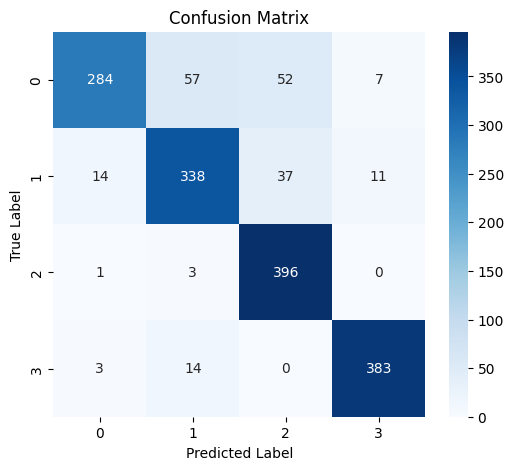


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.71      0.81       400
           1       0.82      0.84      0.83       400
           2       0.82      0.99      0.89       400
           3       0.96      0.96      0.96       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.87      1600
weighted avg       0.88      0.88      0.87      1600



In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, pred_classes))

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

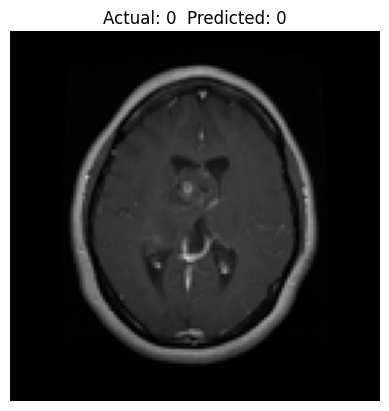

In [29]:
# take different index values.
plt.imshow(X_test[9])
plt.title(f"Actual: {y_test[2]}  Predicted: {pred_classes[2]}")
plt.axis("off")

In [31]:
from PIL import Image
import numpy as np

img = Image.open("/content/brain1.JPG")
img = img.resize((128,128))
img = np.array(img)/255.0
img = img.reshape(1,128,128,3)

prediction = model.predict(img)
print("Predicted class:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
Predicted class: 3


In [33]:
!pip install gradio

In [37]:
import gradio as gr
import numpy as np
from PIL import Image

classes = ['Glioma Tumor','Meningioma Tumor','No Tumor','Pituitary Tumor']

def predict(image):

    image = image.resize((128,128))
    image = np.array(image)/255.0
    image = image.reshape(1,128,128,3)

    pred = model.predict(image)[0]

    class_index = np.argmax(pred)
    confidence = pred[class_index] * 100

    return classes[class_index], f"{confidence:.2f}%"

with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("# 🧠 Brain Tumor Detection System")
    gr.Markdown("Upload an MRI image to predict the tumor type.")

    with gr.Row():
        image_input = gr.Image(type="pil", label="Upload MRI Image")

        with gr.Column():
            tumor_output = gr.Textbox(label="Tumor Type")
            confidence_output = gr.Textbox(label="Confidence")

    predict_btn = gr.Button("Predict")

    predict_btn.click(
        fn=predict,
        inputs=image_input,
        outputs=[tumor_output, confidence_output]
    )

demo.launch()

/tmp/ipykernel_1153/2724009453.py:20: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://156fb8114fc109b104.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
